In [116]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [117]:
df = pd.read_csv('dataset_banco.csv')
print(df.shape)
df.head()


(45215, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


In [118]:
#Revisar variables numericas y categoricas
df.info()
#Existen registros incompletos en algunas celdas

<class 'pandas.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  str    
 2   marital    45214 non-null  str    
 3   education  45214 non-null  str    
 4   default    45215 non-null  str    
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  str    
 7   loan       45215 non-null  str    
 8   contact    45215 non-null  str    
 9   day        45215 non-null  int64  
 10  month      45215 non-null  str    
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  str    
 16  y          45215 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 5.9 MB


## 4 Limpieza
    - 1. Datos faltantes
    - 2. Columnas irrelevantes
    - 3. Registros
    - 4. Valores atipicos (outliers)
    - 5. Errores tipograficos en variables categoricos
    

### 4.1 Datos faltantes

In [119]:
# Eliminamos valores nulos
df.dropna(inplace=True)#inplace=True -> Sobreescribe el resultado de eliminar las filas en el set original
#volvemos a revisar el dataframe 
print(df.shape)
df.info()



(45207, 17)
<class 'pandas.DataFrame'>
Index: 45207 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45207 non-null  int64  
 1   job        45207 non-null  str    
 2   marital    45207 non-null  str    
 3   education  45207 non-null  str    
 4   default    45207 non-null  str    
 5   balance    45207 non-null  float64
 6   housing    45207 non-null  str    
 7   loan       45207 non-null  str    
 8   contact    45207 non-null  str    
 9   day        45207 non-null  int64  
 10  month      45207 non-null  str    
 11  duration   45207 non-null  float64
 12  campaign   45207 non-null  int64  
 13  pdays      45207 non-null  float64
 14  previous   45207 non-null  int64  
 15  poutcome   45207 non-null  str    
 16  y          45207 non-null  str    
dtypes: float64(3), int64(4), str(10)
memory usage: 6.2 MB


### 4.2 Columnas irrelevantes
- Una columa irrelevante puede ser
    - Columnas que contengan informacion irrelevantes para el problema que queremos resolver
    - Variable categorica con 1 solo nivel
    - Variable numerica con 1 solo valor
    - Columnas con info irrelevante
- ***En este caso no se elimina ninguna, pues todas las columnas categoricas tienen mas de 1 subnivel***

In [120]:
# Conteo de los niveles en las diferentes columnas categoricas
col_cat =['job','marital','education','default','housing','loan','contact','month','poutcome','y']
for col in col_cat:
    # Imprime un conte de la cantidad de los diferentes valores 
    print(f'Columa {col}: {df[col].nunique()} subniveles ')

Columa job: 18 subniveles 
Columa marital: 6 subniveles 
Columa education: 10 subniveles 
Columa default: 2 subniveles 
Columa housing: 2 subniveles 
Columa loan: 6 subniveles 
Columa contact: 5 subniveles 
Columa month: 12 subniveles 
Columa poutcome: 6 subniveles 
Columa y: 2 subniveles 


***Podemos ver que ningua columna numerica tiene un solo valor con la desviacion estandar, pues todas son diferentes de 0***

In [121]:
# Columnas numericas
df.describe( )

,age,balance,day,duration,campaign,pdays,previous
count,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000,45207.000000
mean,41.005596,1374.201318,15.806534,258.032539,2.763731,40.178225,0.580198
std,12.037399,3924.491665,8.323015,257.460759,3.098058,100.103283,2.303341
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1427.500000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### 4.3 Filas repetidas


In [122]:
#Tamaño antes de eliminar filas repetidas
print(f'Tamaño antes de eliminar filas repetidas: {df.shape}')
df.drop_duplicates(inplace=True)
print(f'Tamaño despues de eliminar filas repetidas: {df.shape}')


Tamaño antes de eliminar filas repetidas: (45207, 17)
Tamaño despues de eliminar filas repetidas: (45203, 17)


### 4.4 Outliers (Valores atipicos)
- No siempre se deben eliminar los outlies pues puede contener info importante, segun la variable numerica
    


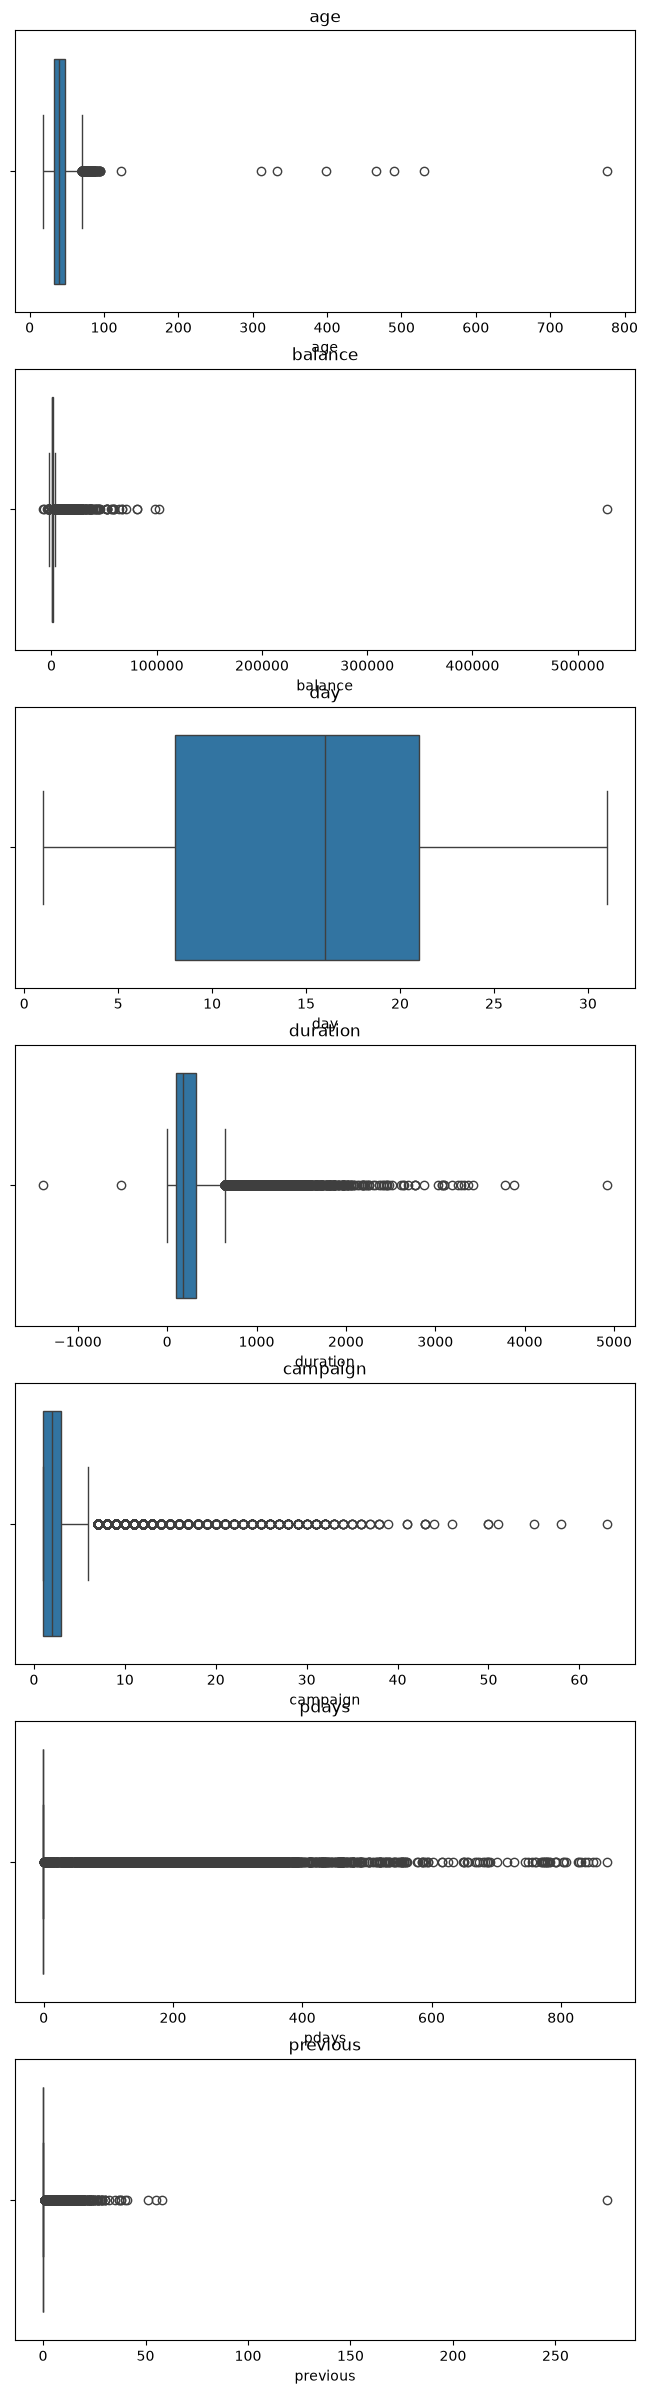

In [123]:
# Generamos un boxpolot para cada variable numerica
num_cols = ['age','balance','day','duration','campaign','pdays','previous']
fig,ax = plt.subplots(nrows=7, ncols=1, figsize=(8,30))
print()
for i, col in enumerate(num_cols):
    sns.boxplot(x=col, data=df, ax=ax[i])
    ax[i].set_title(col)


- En la variable *age*, se pueden observar valores atipicos,pues existen personas con edad mayor a 100
- En la variable *duration* existen valores negativos
- En la variable *previous* hay un valor extremadamente alto, mayor a 300

In [124]:
# Eliminamos filas con age mayor a 100
print(f'Tamaño antes de eliminar ffilas con age mayor a 100: {df.shape}')
df = df[df['age']<=100]
print(f'Tamaño despues de eliminar filas con age mayor a 100: {df.shape}')


Tamaño antes de eliminar ffilas con age mayor a 100: (45203, 17)
Tamaño despues de eliminar filas con age mayor a 100: (45195, 17)


In [125]:
# Eliminamos filas con duration menor a 0
print(f'Tamaño antes de eliminar ffilas con age mayor a 100: {df.shape}')
df = df[df['duration']>0]
print(f'Tamaño despues de eliminar filas con age mayor a 100: {df.shape}')


Tamaño antes de eliminar ffilas con age mayor a 100: (45195, 17)
Tamaño despues de eliminar filas con age mayor a 100: (45190, 17)


In [126]:
# Eliminamos filas con previous > 100 
print(f'Tamaño antes de eliminar ffilas con age mayor a 100: {df.shape}')
df = df[df['previous']<=100]
print(f'Tamaño despues de eliminar filas con age mayor a 100: {df.shape}')


Tamaño antes de eliminar ffilas con age mayor a 100: (45190, 17)
Tamaño despues de eliminar filas con age mayor a 100: (45189, 17)


### Errores tipograficos
- Para este fataframe, existen variables categoricas que pueden aparecer como 'unknown' y 'UNK', que deberian ser equivalentes.

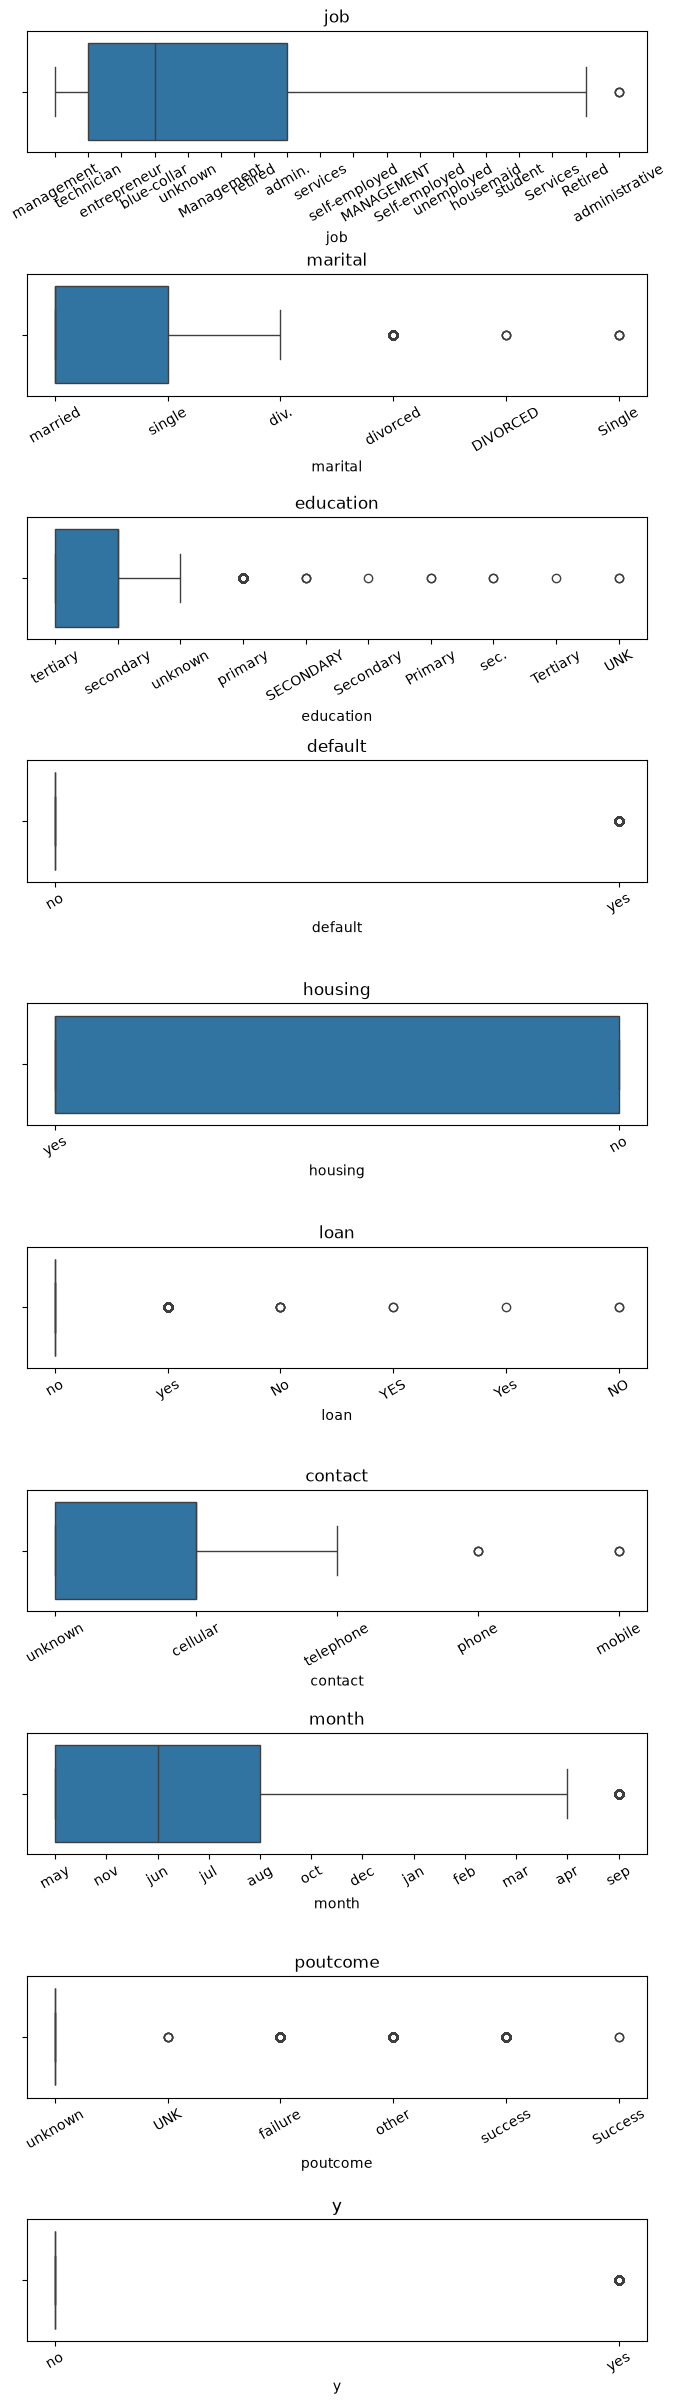

In [127]:
col_cat =['job','marital','education','default','housing','loan','contact','month','poutcome','y']
fig,ax = plt.subplots(nrows=10, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=1)
for i, col in enumerate(col_cat):
    sns.boxplot(x=col, data=df, ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis='x', labelrotation=30)

### Unificar sub-niveles


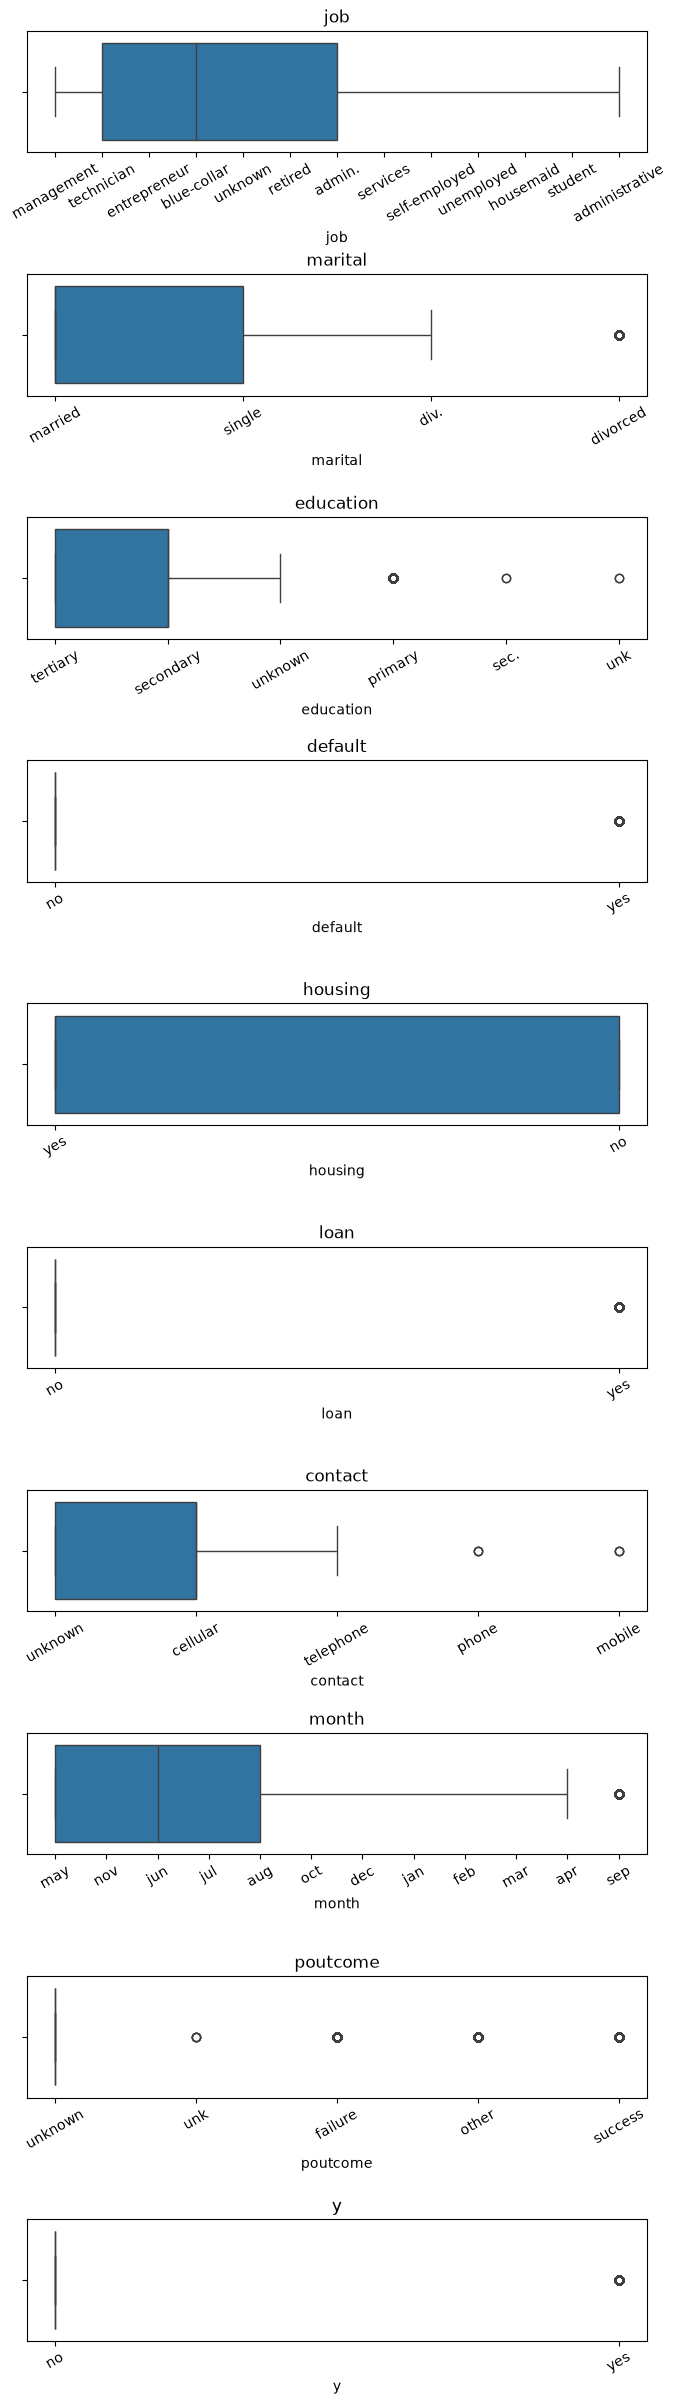

In [128]:
# unificar columnas que tengan diferencia de mayusculas y minusculas 
for columna in df.columns:
    if columna in col_cat:
        df[columna] = df[columna].str.lower()
fig,ax = plt.subplots(nrows=10, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=1)
for i, col in enumerate(col_cat):
    sns.boxplot(x=col, data=df, ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis='x', labelrotation=30)

In [129]:
# para job admin. y administrativo
df['job']= df['job'].str.replace('admin.', 'administrative', regex= False)

In [130]:
# Similar div y divorced
df['marital'] = df['marital'].str.replace('div.','divorced', regex=False)

In [131]:
# Para la columna de education quitamos sec por secondary y unk por unknown
df.loc[df['education']=='sec.', 'education'] = 'secondary'
df.loc[df['education']=='unk','education'] = 'unknown' 

In [132]:
# En contacto uniifcamos phone con telephone y mobile con celular
df.loc[df['contact']=='phone','contact'] = 'telephone'
df.loc[df['contact']=='mobile','contact'] = 'cellular'

In [133]:
df['poutcome']= df['poutcome'].str.replace('unknownnown', 'unknown', regex= False)

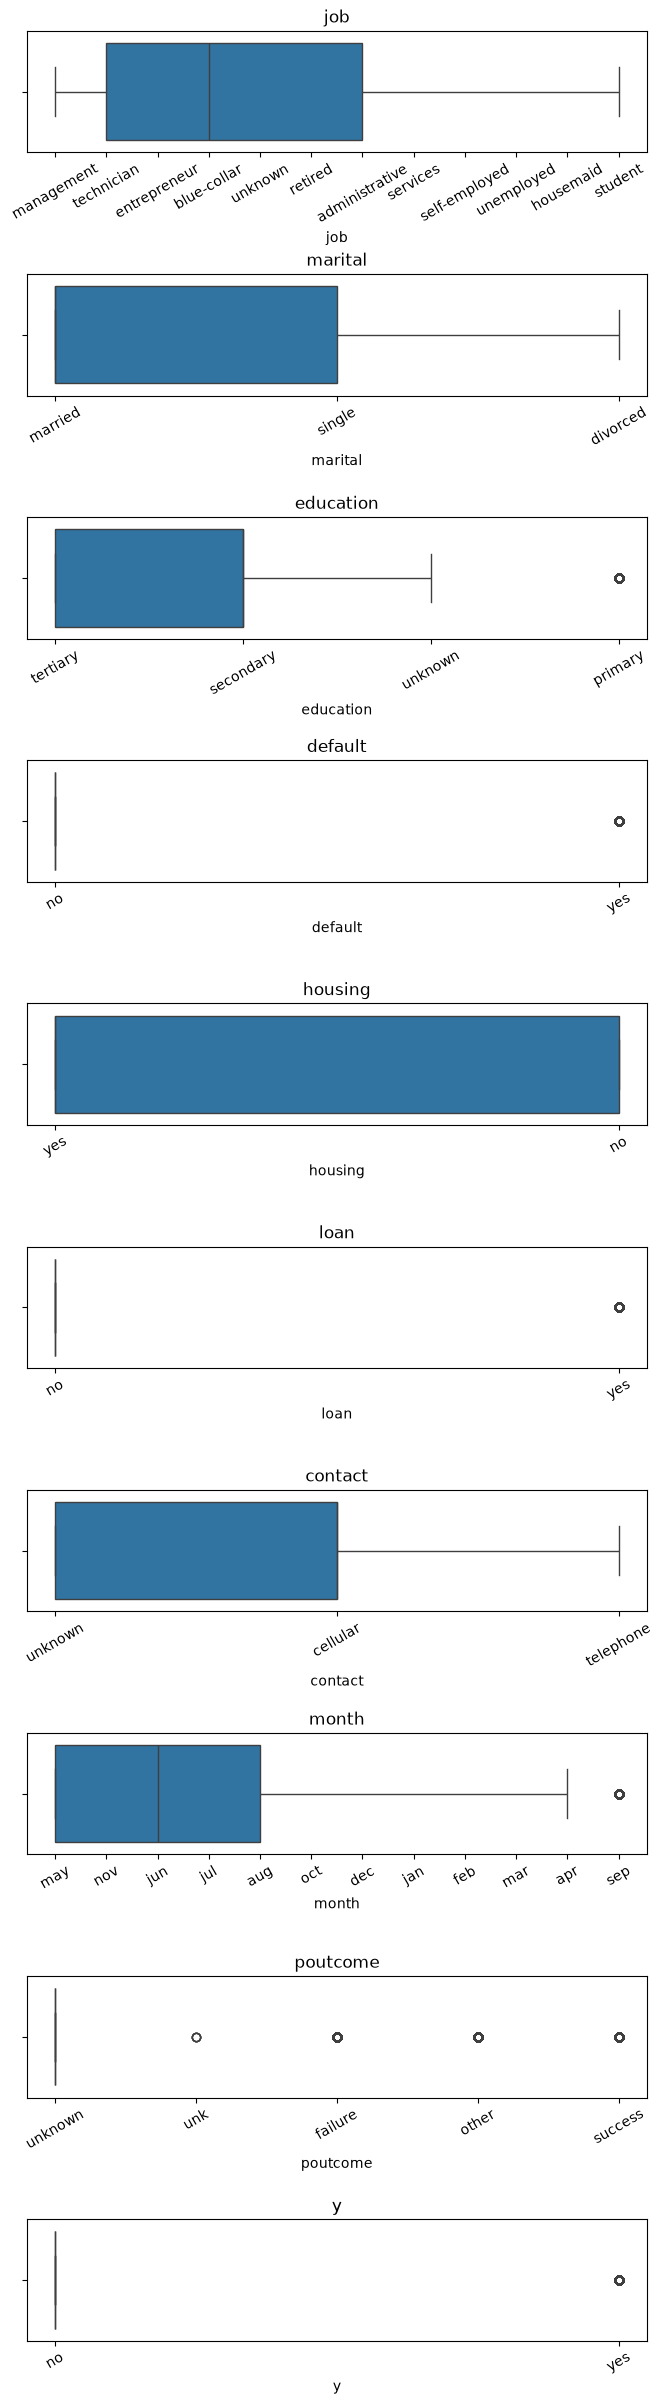

In [134]:
fig,ax = plt.subplots(nrows=10, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=1)
for i, col in enumerate(col_cat):
    sns.boxplot(x=col, data=df, ax=ax[i])
    ax[i].set_title(col)
    ax[i].tick_params(axis='x', labelrotation=30)

In [135]:
print(df.shape)

(45189, 17)


### Originalmente teniamos 45215 registros y 17 columnas. Con la limpieza el dataset resultante fue de 45189 registros y 17 columnas

In [136]:
df.to_csv('dataset_banco_clean.csv',index=False)